<img src="https://planet-sdk-for-python.readthedocs.io/en/latest/images/Planet_primarymark_RGB_White.png" width="100"/>

# PlanetScope SuperRes

This notebook demonstrates how to use Planet's **SuperRes** feature to enhance PlanetScope imagery from its native 3 m/px ground sample distance (GSD) to 2 m/px using an AI-powered model hosted on Sentinel Hub.

SuperRes applies a trained deep-learning model via the Sentinel Hub Process API. The model takes PlanetScope Surface Reflectance (SR) data as input and returns enhanced-resolution imagery along with a per-pixel confidence layer.

**What you will learn:**
- Authenticate with Sentinel Hub using OAuth client credentials
- Load an AOI from a GeoJSON file and compute UTM pixel dimensions
- Fetch standard PlanetScope RGB imagery at native 3 m resolution
- Apply the SuperRes model to get 2 m imagery
- Visualize and compare standard vs. super-resolved results

## Documentation

- [Planet Docs](https://docs.planet.com/)
- [Planet Authentication](https://docs.planet.com/develop/authentication/)
- [Sentinel Hub Process API](https://docs.sentinel-hub.com/api/latest/api/process/)
- [sentinelhub-py SDK](https://sentinelhub-py.readthedocs.io/en/latest/)
- [Planet Notebooks repo](https://github.com/planetlabs/notebooks)

## Requirements

Install the required packages before running this notebook:

```bash
pip install sentinelhub geopandas matplotlib numpy contextily
```

You will also need:
- A Planet account with access to Sentinel Hub
- Sentinel Hub OAuth client credentials (`SH_CLIENT_ID` and `SH_CLIENT_SECRET`)

## Authentication

This notebook authenticates with Sentinel Hub using OAuth 2.0 client credentials. Set the following environment variables before running:

```bash
export SH_CLIENT_ID="your-client-id"
export SH_CLIENT_SECRET="your-client-secret"
```

You can find your credentials in the [Planet account dashboard](https://insights.planet.com/account/#/).

In [7]:
import os
import pprint

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import sentinelhub as sh

# Load credentials from environment variables
SH_CLIENT_ID = os.environ.get("SH_CLIENT_ID")
SH_CLIENT_SECRET = os.environ.get("SH_CLIENT_SECRET")

if not SH_CLIENT_ID or not SH_CLIENT_SECRET:
    raise ValueError(
        "SH_CLIENT_ID and SH_CLIENT_SECRET environment variables must be set. "
        "Find your credentials at https://insights.planet.com/account/#/"
    )


config = sh.SHConfig(
    sh_client_id=SH_CLIENT_ID,
    sh_client_secret=SH_CLIENT_SECRET,
)
config.sh_base_url = "https://services.sentinel-hub.com"
try:
    sh.SentinelHubSession(config=config).token
    print("Successfully authenticated with Sentinel Hub")
except Exception as e:
    raise RuntimeError(f"Sentinel Hub authentication failed: {e}") from e

Successfully authenticated with Sentinel Hub


## Define Area of Interest

The AOI is a ~1.5 km × 1.5 km area over central Cairo, Egypt. It is stored in `Cairo_SuperRes.geojson`. We load it with GeoPandas, extract the bounding box, and display it on a map.

AOI bounding box (WGS84):
  Min longitude: 31.455342
  Min latitude:  30.045962
  Max longitude: 31.473012
  Max latitude:  30.060080


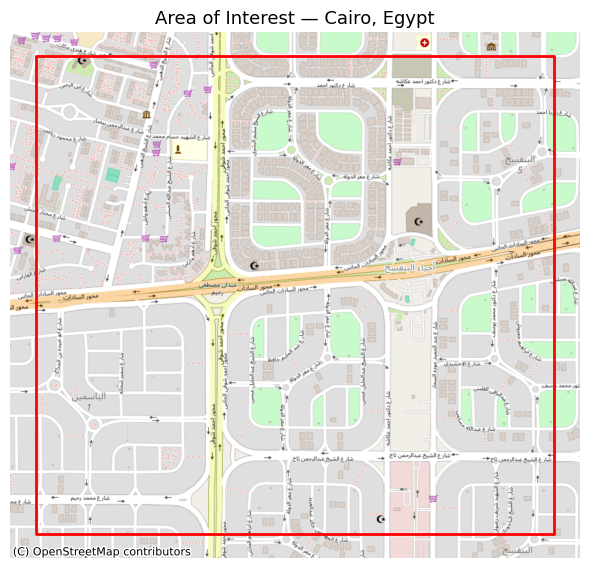

In [8]:
# Load AOI
aoi_gdf = gpd.read_file("Cairo_SuperRes.geojson")

# Extract bounding box as [minLon, minLat, maxLon, maxLat]
bounds = aoi_gdf.total_bounds  # [minx, miny, maxx, maxy]
bbox_wgs84 = [bounds[0], bounds[1], bounds[2], bounds[3]]

print("AOI bounding box (WGS84):")
print(f"  Min longitude: {bbox_wgs84[0]:.6f}")
print(f"  Min latitude:  {bbox_wgs84[1]:.6f}")
print(f"  Max longitude: {bbox_wgs84[2]:.6f}")
print(f"  Max latitude:  {bbox_wgs84[3]:.6f}")

# Visualize with OSM basemap
aoi_web = aoi_gdf.to_crs(epsg=3857)  # contextily expects Web Mercator

fig, ax = plt.subplots(figsize=(6, 6))
aoi_web.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("Area of Interest — Cairo, Egypt", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Configure Scene Parameters

We set the collection ID, date, and evalscript IDs. Then we compute the UTM CRS for the AOI center and derive pixel dimensions:

- **Output (SuperRes):** 2 m/px GSD
- **Input (standard):** 3 m/px GSD = output dimensions ÷ 1.5

Using a true UTM projection avoids distortion that would occur with Web Mercator at non-equatorial latitudes.

In [13]:
# Scene parameters
COLLECTION = "28eef896-9632-4546-a99e-cea34d74b21e"  # PlanetScope SR 8-band (Sandbox)
DATE = "2023-12-30"

# SuperRes evalscript ID (stored model, EU deployment)
SUPERRES_EVALSCRIPT_ID = "5a780173-89fc-4f39-9f99-a024f256c713"
SUPERRES_PARAMS = {"buffer": 10, "blockSize": 204}

# Resolution settings
OUTPUT_RESOLUTION = 2  # meters per pixel (SuperRes output)
INPUT_RESOLUTION = 3  # meters per pixel (native PlanetScope)


def get_bbox_dimensions_in_utm(bbox_wgs84, resolution):
    """
    Convert a WGS84 bounding box to UTM pixel dimensions at a given resolution.

    Args:
        bbox_wgs84: [minLon, minLat, maxLon, maxLat]
        resolution: target ground sample distance in meters

    Returns:
        dict with width, height, utm_bbox (bounds tuple), and utm_crs
    """
    minLon, minLat, maxLon, maxLat = bbox_wgs84
    center_lon = (minLon + maxLon) / 2
    center_lat = (minLat + maxLat) / 2

    utm_crs = sh.get_utm_crs(center_lon, center_lat)
    utm_bbox = sh.BBox(bbox=bbox_wgs84, crs=sh.CRS("EPSG:4326")).transform(utm_crs)
    bounds = utm_bbox.geometry.bounds  # (minx, miny, maxx, maxy) in UTM meters

    width = round((bounds[2] - bounds[0]) / resolution)
    height = round((bounds[3] - bounds[1]) / resolution)

    return {
        "width": width,
        "height": height,
        "utm_bbox": bounds,
        "utm_crs": utm_crs,
        "width_meters": bounds[2] - bounds[0],
        "height_meters": bounds[3] - bounds[1],
    }


# Compute output (2 m) and input (3 m) dimensions
output_dims = get_bbox_dimensions_in_utm(bbox_wgs84, resolution=OUTPUT_RESOLUTION)
input_dims = get_bbox_dimensions_in_utm(bbox_wgs84, resolution=INPUT_RESOLUTION)

UTM_CRS = output_dims["utm_crs"]
UTM_BBOX = output_dims["utm_bbox"]  # (minx, miny, maxx, maxy)
UTM_EPSG = UTM_CRS.epsg

OUTPUT_WIDTH = output_dims["width"]
OUTPUT_HEIGHT = output_dims["height"]
INPUT_WIDTH = input_dims["width"]
INPUT_HEIGHT = input_dims["height"]

print(f"UTM CRS: EPSG:{UTM_EPSG}")
print(
    f"Ground coverage: {output_dims['width_meters']:.0f} m × {output_dims['height_meters']:.0f} m"
)
print(f"Standard (3 m):  {INPUT_WIDTH} × {INPUT_HEIGHT} px")
print(f"SuperRes (2 m):  {OUTPUT_WIDTH} × {OUTPUT_HEIGHT} px")

UTM CRS: EPSG:32636
Ground coverage: 1725 m × 1542 m
Standard (3 m):  575 × 514 px
SuperRes (2 m):  862 × 771 px


## Fetch Standard PlanetScope Imagery (3 m)

We request a true-color (RGB) composite from the PlanetScope Surface Reflectance collection at its native 3 m resolution using an inline evalscript. The response is a multi-band GeoTIFF.

In [10]:
# Inline evalscript for standard PlanetScope RGB


RGB_EVALSCRIPT = """
//VERSION=3

function setup() {
    return {
        input: ["blue", "green", "red", "dataMask"],
        output: {
            bands: 4,
            sampleType: "UINT16"
        }
    };
}

function evaluatePixel(sample) {
    return [
        sample.red,
        sample.green,
        sample.blue,
        sample.dataMask
    ];
}
"""


def fetch_tiff_image(
    utm_bbox, epsg, date, width, height, evalscript, collection, evalscript_params=None
) -> np.ndarray:
    """
    Send a request to the Sentinel Hub Process API v1 and return TIFF bytes.

    Args:
        utm_bbox: (minx, miny, maxx, maxy) in UTM meters
        epsg: EPSG code for the UTM CRS
        date: acquisition date as "YYYY-MM-DD"
        width: output image width in pixels
        height: output image height in pixels
        evalscript: inline evalscript string, or stored evalscript ID
        collection: BYOC collection ID
        evalscript_params: optional dict passed as evalscriptParams (for SuperRes)

    Returns:
        np.ndarray:
    """
    request = sh.SentinelHubRequest(
        evalscript=evalscript,
        input_data=[
            sh.SentinelHubRequest.input_data(
                data_collection=sh.DataCollection.define_byoc(collection),
                time_interval=(f"{date}T00:00:00Z", f"{date}T23:59:59Z"),
                mosaicking_order=sh.MosaickingOrder.MOST_RECENT,
                upsampling=sh.ResamplingType.BILINEAR,
                downsampling=sh.ResamplingType.BILINEAR,
            )
        ],
        responses=[sh.SentinelHubRequest.output_response("default", sh.MimeType.TIFF)],
        bbox=sh.BBox(bbox=utm_bbox, crs=sh.CRS(f"EPSG:{epsg}")),
        size=(width, height),
        config=config,
    )
    if evalscript_params:
        request.payload["evalscriptParams"] = evalscript_params

    print("Sending request to Sentinel Hub...")
    pprint.pprint(request.payload)

    return request.get_data()[0]


# Fetch standard RGB at 3 m
print(
    f"Fetching standard PlanetScope RGB ({INPUT_WIDTH} × {INPUT_HEIGHT} px at 3 m/px)..."
)
standard_tiffs = fetch_tiff_image(
    utm_bbox=UTM_BBOX,
    epsg=UTM_EPSG,
    date=DATE,
    width=INPUT_WIDTH,
    height=INPUT_HEIGHT,
    evalscript=RGB_EVALSCRIPT,
    collection=COLLECTION,
)
print(f"Received {standard_tiffs.shape} array")

Fetching standard PlanetScope RGB (575 × 514 px at 3 m/px)...
Sending request to Sentinel Hub...
{'evalscript': '\n'
               '//VERSION=3\n'
               '\n'
               'function setup() {\n'
               '    return {\n'
               '        input: ["blue", "green", "red", "dataMask"],\n'
               '        output: {\n'
               '            bands: 4,\n'
               '            sampleType: "UINT16"\n'
               '        }\n'
               '    };\n'
               '}\n'
               '\n'
               'function evaluatePixel(sample) {\n'
               '    return [\n'
               '        sample.red,\n'
               '        sample.green,\n'
               '        sample.blue,\n'
               '        sample.dataMask\n'
               '    ];\n'
               '}\n',
 'input': {'bounds': {'bbox': [351080.9693515829,
                               3324883.531882848,
                               352805.5441665278,
                   

## Apply SuperRes Model (2 m)

The SuperRes model is invoked by referencing a **stored evalscript ID** instead of an inline evalscript. Additional model parameters (`buffer` and `blockSize`) are passed via `evalscriptParams`.

The response TIFF contains 6 bands that follow the PlanetScope source band ordering:
- Band 1: Blue (super-resolved)
- Band 2: Green (super-resolved)
- Band 3: Red (super-resolved)
- Band 5: Confidence score (0–100)
- Band 6: Alpha/DataMask

In [11]:
print(f"Fetching SuperRes imagery ({OUTPUT_WIDTH} × {OUTPUT_HEIGHT} px at 2 m/px)...")
superres_tiffs = fetch_tiff_image(
    utm_bbox=UTM_BBOX,
    epsg=UTM_EPSG,
    date=DATE,
    width=OUTPUT_WIDTH,
    height=OUTPUT_HEIGHT,
    evalscript=SUPERRES_EVALSCRIPT_ID,
    collection=COLLECTION,
    evalscript_params=SUPERRES_PARAMS,
)
print(f"Received {superres_tiffs.shape} array")

Fetching SuperRes imagery (862 × 771 px at 2 m/px)...
Sending request to Sentinel Hub...
{'evalscript': '5a780173-89fc-4f39-9f99-a024f256c713',
 'evalscriptParams': {'blockSize': 204, 'buffer': 10},
 'input': {'bounds': {'bbox': [351080.9693515829,
                               3324883.531882848,
                               352805.5441665278,
                               3326425.4037106703],
                      'properties': {'crs': 'http://www.opengis.net/def/crs/EPSG/0/32636'}},
           'data': [InputDataDict({'type': 'byoc-28eef896-9632-4546-a99e-cea34d74b21e', 'dataFilter': {'timeRange': {'from': '2023-12-30T00:00:00Z', 'to': '2023-12-30T23:59:59Z'}, 'mosaickingOrder': 'mostRecent'}, 'processing': {'upsampling': 'BILINEAR', 'downsampling': 'BILINEAR'}}, service_url=None)]},
 'output': {'height': 771,
            'responses': [{'format': {'type': 'image/tiff'},
                           'identifier': 'default'}],
            'width': 862}}
Received (771, 862, 6) array


## Visualize and Compare Results

We parse both TIFFs and display a 3-panel comparison:
1. **Standard RGB** — 3 m native PlanetScope
2. **SuperRes RGB** — 2 m AI-enhanced
3. **Confidence layer** — per-pixel model confidence (0–100)

Standard:  575 x 514 px, 4 bands
SuperRes:  862 x 771 px, 6 bands
Confidence: min=44, max=100, mean=88.1


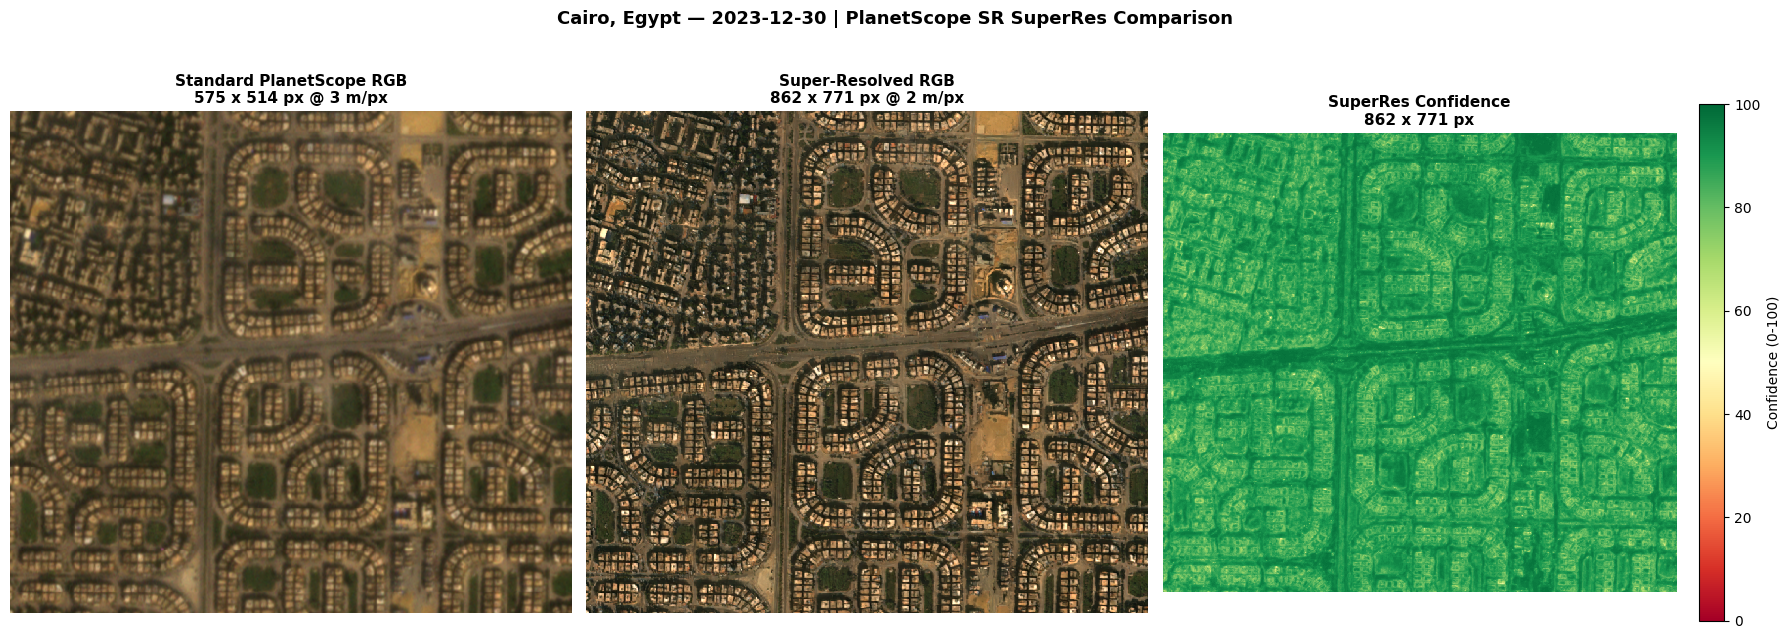

In [12]:
def parse_tiff(img_array, superres=False):
    """
    Parse a TIFF response from the Sentinel Hub Process API.

    Args:
        img_array: numpy array representing the TIFF image

        superres: set True for SuperRes output, whose bands follow the PlanetScope
                  source band ordering (Blue=1, Green=2, Red=3). Reorders to RGB
                  for display. Leave False for standard evalscript output where
                  evaluatePixel explicitly returns [Red, Green, Blue].

    Returns a dict with:
      - rgb: (H, W, 3) float array normalized to [0, 1] for display
      - confidence: (H, W) uint8 array in range [0, 100], or None
      - alpha: (H, W) array, or None
      - num_bands: total number of bands
    """

    num_bands = img_array.shape[2]
    # SuperRes output: Blue(band 1), Green(band 2), Red(band 3) -> reorder to RGB
    # Standard output: evaluatePixel returns [Red, Green, Blue] -> already RGB
    if superres:
        rgb = img_array[:, :, [2, 1, 0]]  # reorder BGR to RGB
        rgb = np.clip(rgb / 100, 0, 1)  # normalize from PlanetScope SR range (0-255)
    else:
        rgb = img_array[..., :3]
        rgb = np.clip(
            rgb * 2.55 / 10000, 0, 1
        )  # normalize from PlanetScope SR range (0-1000)

    confidence = img_array[:, :, 4] if num_bands >= 5 else None
    alpha = img_array[:, :, 5] if num_bands >= 6 else None

    return {
        "rgb": rgb,
        "confidence": confidence,
        "alpha": alpha,
        "num_bands": num_bands,
    }


# Standard: evalscript evaluatePixel returns [Red, Green, Blue] -> superres=False
# SuperRes: model output follows source band order Blue(1), Green(2), Red(3) -> superres=True
standard = parse_tiff(standard_tiffs, superres=False)
superres = parse_tiff(superres_tiffs, superres=True)

print(
    f"Standard:  {standard['rgb'].shape[1]} x {standard['rgb'].shape[0]} px, {standard['num_bands']} bands"
)
print(
    f"SuperRes:  {superres['rgb'].shape[1]} x {superres['rgb'].shape[0]} px, {superres['num_bands']} bands"
)
if superres["confidence"] is not None:
    conf = superres["confidence"]
    print(f"Confidence: min={conf.min()}, max={conf.max()}, mean={conf.mean():.1f}")

# 3-panel comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

axes[0].imshow(standard["rgb"], interpolation="none")
axes[0].set_title(
    f"Standard PlanetScope RGB\n{standard['rgb'].shape[1]} x {standard['rgb'].shape[0]} px @ 3 m/px",
    fontsize=11,
    fontweight="bold",
)
axes[0].axis("off")

axes[1].imshow(superres["rgb"], interpolation="none")
axes[1].set_title(
    f"Super-Resolved RGB\n{superres['rgb'].shape[1]} x {superres['rgb'].shape[0]} px @ 2 m/px",
    fontsize=11,
    fontweight="bold",
)
axes[1].axis("off")

if superres["confidence"] is not None:
    im = axes[2].imshow(
        superres["confidence"], cmap="RdYlGn", vmin=0, vmax=100, interpolation="none"
    )
    axes[2].set_title(
        f"SuperRes Confidence\n{superres['confidence'].shape[1]} x {superres['confidence'].shape[0]} px",
        fontsize=11,
        fontweight="bold",
    )
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Confidence (0-100)")
axes[2].axis("off")

fig.suptitle(
    f"Cairo, Egypt — {DATE} | PlanetScope SR SuperRes Comparison",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. Authenticated with Sentinel Hub using OAuth client credentials
2. Loaded a Cairo, Egypt AOI from a GeoJSON file and computed UTM pixel dimensions
3. Fetched a standard PlanetScope RGB image at **3 m/px** using an inline evalscript
4. Applied the **SuperRes model** to obtain a **2 m/px** enhanced image, along with a per-pixel confidence layer
5. Visualized the results in a side-by-side comparison

### Next steps

- Try your own AOI by replacing `Cairo_SuperRes.geojson` with a different bounding polygon
- Explore other Planet Sandbox Data scenes by changing the `DATE` and `COLLECTION` parameters
- For large-area processing, consider the [Sentinel Hub Batch Process API (BatchV2)](https://docs.sentinel-hub.com/api/latest/api/batchv2/) to tile and process many scenes in parallel